In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import ListedColormap

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score, cohen_kappa_score
from sklearn.svm import SVC

The AQI category *“Poor”* contained only 10 samples, leading to a significant class imbalance during SVM training. This imbalance was reflected in the evaluation metrics, where the macro-average F1-score was approximately 71%, while the weighted-average F1-score was much higher at around 96%. Attempts to address this issue by assigning a higher class weight to the *“Poor”* category did not result in any substantial improvement. Consequently, it was deemed more effective to merge the *“Poor”* AQI category with the *“Moderate”* category.

In [2]:
df = pd.read_csv('../../data/india_city_aqi_2015_2023-cleaned_dataset.csv')
df["aqi_category"] = df["aqi_category"].replace({
    "Poor": "Moderate"
})
df['aqi_category'].value_counts()

aqi_category
Satisfactory    17244
Moderate        11443
Good             4183
Name: count, dtype: int64

In [3]:
df.head(10)

,city,date,pm2.5,pm10,no2,so2,co,o3,aqi,aqi_category,pm2.5/pm10 ratio,season
0,Delhi,2015-01-01,99.868566,147.103280,49.715328,19.615149,0.729754,46.487946,103,Moderate,0.678901,Winter
1,Delhi,2015-01-02,143.168513,208.517207,32.957884,14.712800,0.660975,43.014054,141,Moderate,0.686603,Winter
2,Delhi,2015-01-03,89.678491,101.412886,14.126233,9.188562,0.496151,54.713710,82,Satisfactory,0.884291,Winter
3,Delhi,2015-01-04,43.679037,65.432963,61.984732,10.871118,0.820258,28.628777,50,Good,0.667539,Winter
4,Delhi,2015-01-05,58.224691,110.443143,22.735096,13.878490,0.619808,45.624594,69,Satisfactory,0.527192,Winter
5,Delhi,2015-01-06,55.931736,142.977299,39.797542,6.711445,1.046763,31.687345,78,Satisfactory,0.391193,Winter
6,Delhi,2015-01-07,88.354544,99.161141,20.077209,12.984306,1.021540,52.570524,81,Satisfactory,0.891020,Winter
7,Delhi,2015-01-08,75.374069,119.351995,17.822170,8.400779,0.661808,65.856833,81,Satisfactory,0.631528,Winter
8,Delhi,2015-01-09,93.744732,108.483929,44.861260,10.074589,0.596923,59.175144,89,Satisfactory,0.864135,Winter
9,Delhi,2015-01-10,121.239981,189.865583,27.411737,10.453938,0.899379,64.633177,126,Moderate,0.638557,Winter


In [4]:
X = df.drop(['date','aqi_category'],axis = 1)
X = pd.get_dummies(X,columns=["city","season"])#one hot encoding citites and seasons
y = df['aqi_category']

In [5]:
X.head(10)

,pm2.5,pm10,no2,so2,co,o3,aqi,pm2.5/pm10 ratio,city_Ahmedabad,city_Bengaluru,...,city_Hyderabad,city_Jaipur,city_Kolkata,city_Lucknow,city_Mumbai,city_Pune,season_Monsoon,season_Post-Monsoon,season_Summer,season_Winter
0,99.868566,147.103280,49.715328,19.615149,0.729754,46.487946,103,0.678901,False,False,...,False,False,False,False,False,False,False,False,False,True
1,143.168513,208.517207,32.957884,14.712800,0.660975,43.014054,141,0.686603,False,False,...,False,False,False,False,False,False,False,False,False,True
2,89.678491,101.412886,14.126233,9.188562,0.496151,54.713710,82,0.884291,False,False,...,False,False,False,False,False,False,False,False,False,True
3,43.679037,65.432963,61.984732,10.871118,0.820258,28.628777,50,0.667539,False,False,...,False,False,False,False,False,False,False,False,False,True
4,58.224691,110.443143,22.735096,13.878490,0.619808,45.624594,69,0.527192,False,False,...,False,False,False,False,False,False,False,False,False,True
5,55.931736,142.977299,39.797542,6.711445,1.046763,31.687345,78,0.391193,False,False,...,False,False,False,False,False,False,False,False,False,True
6,88.354544,99.161141,20.077209,12.984306,1.021540,52.570524,81,0.891020,False,False,...,False,False,False,False,False,False,False,False,False,True
7,75.374069,119.351995,17.822170,8.400779,0.661808,65.856833,81,0.631528,False,False,...,False,False,False,False,False,False,False,False,False,True
8,93.744732,108.483929,44.861260,10.074589,0.596923,59.175144,89,0.864135,False,False,...,False,False,False,False,False,False,False,False,False,True
9,121.239981,189.865583,27.411737,10.453938,0.899379,64.633177,126,0.638557,False,False,...,False,False,False,False,False,False,False,False,False,True


In [6]:
y.head(5)

0        Moderate
1        Moderate
2    Satisfactory
3            Good
4    Satisfactory
Name: aqi_category, dtype: str

In [7]:
print(X.shape,y.shape)

(32870, 22) (32870,)


In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42,stratify = y)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### The processing is performed using  Radial Basis Function (RBF) as the kernel

In [10]:
model = SVC(kernel='rbf',C = 10, gamma = 'scale')
model.fit(X_train_scaled,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [11]:
y_pred = model.predict(X_test_scaled)

## Performance Evaluation

In [12]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.9870702768481898
              precision    recall  f1-score   support

        Good       0.97      0.98      0.98       837
    Moderate       0.99      0.99      0.99      2288
Satisfactory       0.99      0.99      0.99      3449

    accuracy                           0.99      6574
   macro avg       0.98      0.99      0.98      6574
weighted avg       0.99      0.99      0.99      6574



In [13]:
macro_f1 = f1_score(y_test, y_pred, average='macro')
print("Macro F1:", macro_f1)

Macro F1: 0.984544863085944


In [14]:
scores = cross_val_score(model, X, y, cv=5, scoring='f1_macro')

print("Cross-val Macro F1:", scores.mean())
print("Std Dev:", scores.std())

Cross-val Macro F1: 0.9992054489626045
Std Dev: 0.0008520391103044213


In [15]:
print("Train Accuracy:", model.score(X_train_scaled, y_train))
print("Test Accuracy:", model.score(X_test_scaled, y_test))

Train Accuracy: 0.9978323699421965
Test Accuracy: 0.9870702768481898


In [16]:
kappa = cohen_kappa_score(y_test, y_pred)
print("Kappa Score:", kappa)

Kappa Score: 0.9780019041212289


### Visualization

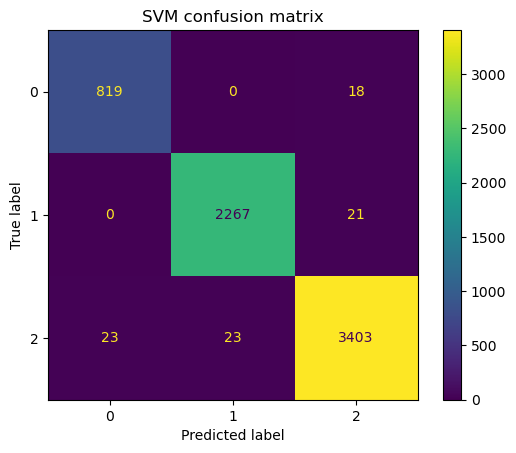

In [17]:
labels = ["Good","Moderate","Satisfactory"]

cm = confusion_matrix(y_test,y_pred,labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()

plt.title("SVM confusion matrix")
plt.show()

<Axes: xlabel='season', ylabel='aqi'>

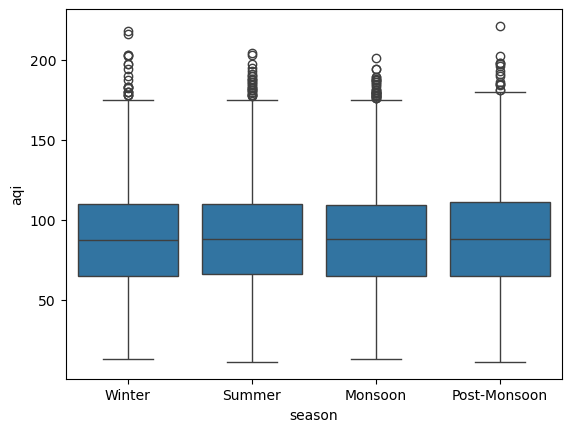

In [18]:
sns.boxplot(x = df['season'], y = df['aqi'])